# Evaluación de Modelos Predictivos

En este notebook se evalúa el desempeño de los modelos de clasificación entrenados previamente para predecir la cancelación de clientes (churn) en TelecomX.

A partir del dataset preprocesado, se reconstruirá la división entre entrenamiento y prueba con el fin de generar las predicciones de los modelos y analizar su rendimiento utilizando diferentes métricas de evaluación.

## Objetivos del notebook

- Cargar el dataset procesado utilizado para el entrenamiento de los modelos.
- Separar las variables predictoras y la variable objetivo.
- Dividir los datos en conjuntos de entrenamiento y prueba.
- Entrenar nuevamente los modelos para su evaluación.
- Calcular métricas de desempeño como **accuracy, precision, recall y F1-score**.
- Visualizar los resultados mediante **matrices de confusión y curvas ROC**.
- Comparar el rendimiento de los modelos para identificar cuál ofrece mejores resultados en la predicción de cancelación de clientes.

Este análisis permitirá determinar qué modelo presenta un mejor equilibrio entre capacidad predictiva y detección de clientes con riesgo de abandono.

##Montar Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##Importar las librerías necesarias

In [2]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

##Definimos la ruta del proyecto

In [3]:
PROJECT_PATH = "/content/drive/MyDrive/TelecomX_Churn_ML"
DATA_PATH = os.path.join(PROJECT_PATH, "data", "processed")

dataset_path = os.path.join(DATA_PATH, "TelecomX_model_ready.csv")

print("Ruta del dataset:", dataset_path)

Ruta del dataset: /content/drive/MyDrive/TelecomX_Churn_ML/data/processed/TelecomX_model_ready.csv


##Cargamos el dataset

In [4]:
df = pd.read_csv(dataset_path)
df.head()

,abandono,adulto_mayor,tiene_pareja,tiene_dependientes,antiguedad_meses,servicio_telefono,lineas_multiples,proteccion_dispositivo,soporte_tecnico,streaming_tv,...,servicio_internet_No,seguridad_online_No internet service,seguridad_online_Yes,respaldo_online_No internet service,respaldo_online_Yes,tipo_contrato_One year,tipo_contrato_Two year,metodo_pago_Credit card (automatic),metodo_pago_Electronic check,metodo_pago_Mailed check
0,0,0,1,1,9,1,0,0,1,1,...,False,False,False,False,True,True,False,False,False,True
1,0,0,0,0,9,1,1,0,0,0,...,False,False,False,False,False,False,False,False,False,True
2,1,0,0,0,4,1,0,1,0,0,...,False,False,False,False,False,False,False,False,True,False
3,1,1,1,0,13,1,0,1,0,1,...,False,False,False,False,True,False,False,False,True,False
4,1,1,1,0,3,1,0,0,1,1,...,False,False,False,False,False,False,False,False,False,True


##Separamos las variables

In [5]:
X = df.drop("abandono", axis=1)
y = df["abandono"]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (7032, 26)
Dimensiones de y: (7032,)


##División de los datos para Train y Test

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

##Escalar variables continuas para RL

In [7]:
continuous_cols = ["antiguedad_meses", "cargo_mensual", "cargo_total", "cargo_diario"]

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

scaler = StandardScaler()

X_train_scaled[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test_scaled[continuous_cols] = scaler.transform(X_test[continuous_cols])

##Entrenamos los modelos

In [8]:
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train_scaled, y_train)

random_forest_model = RandomForestClassifier(random_state=42)
random_forest_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

##Generamos predicciones

In [9]:
y_pred_logistic = logistic_model.predict(X_test_scaled)
y_pred_rf = random_forest_model.predict(X_test)

y_prob_logistic = logistic_model.predict_proba(X_test_scaled)[:, 1]
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

## Evaluación de los modelos

En esta sección se comparará el desempeño de los modelos entrenados utilizando métricas de clasificación.

Debido a que el problema presenta un desbalance moderado entre clases, no se evaluará únicamente la accuracy, sino también métricas como **precision, recall y F1-score**, que permiten analizar mejor la capacidad del modelo para identificar clientes con riesgo de cancelación.

##Calculo de las métricas

In [10]:
metrics_df = pd.DataFrame({
    "Modelo": ["Regresión Logística", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_logistic),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_logistic),
        recall_score(y_test, y_pred_rf)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_logistic),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_logistic),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

metrics_df

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Regresión Logística,0.802370,0.656522,0.538324,0.591577,0.845308
1,Random Forest,0.780569,0.612903,0.474153,0.534673,0.821128


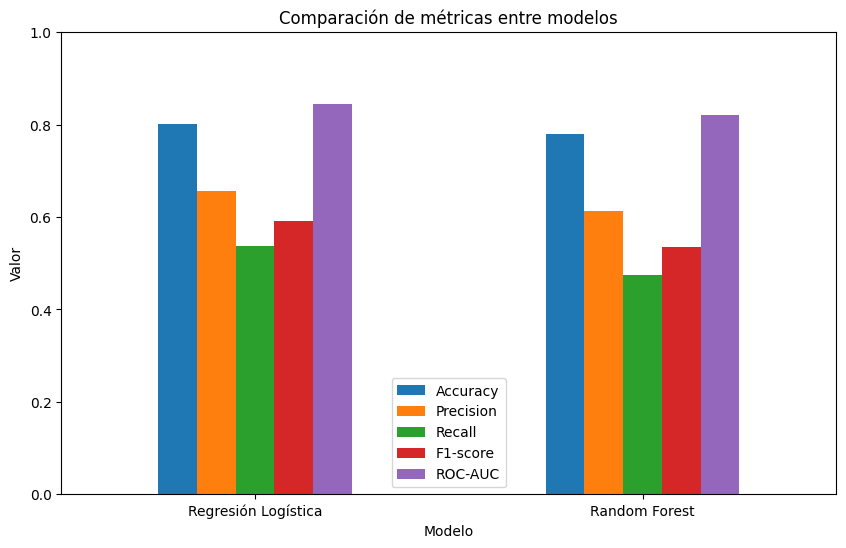

In [11]:
metrics_plot = metrics_df.set_index("Modelo")

metrics_plot.plot(kind="bar", figsize=(10,6))
plt.title("Comparación de métricas entre modelos")
plt.ylabel("Valor")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.show()

##Matriz de confusión

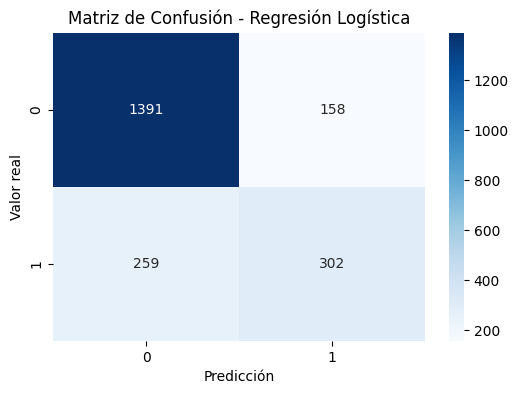

In [12]:
cm_logistic = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(6,4))
sns.heatmap(cm_logistic, annot=True, fmt="d", cmap="Blues")

plt.title("Matriz de Confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

In [13]:
print("Classification Report - Regresión Logística")
print(classification_report(y_test, y_pred_logistic))

Classification Report - Regresión Logística
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1549
           1       0.66      0.54      0.59       561

    accuracy                           0.80      2110
   macro avg       0.75      0.72      0.73      2110
weighted avg       0.79      0.80      0.80      2110



In [14]:
print("Classification Report - Regresión Logística")
print(classification_report(y_test, y_pred_logistic))

Classification Report - Regresión Logística
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1549
           1       0.66      0.54      0.59       561

    accuracy                           0.80      2110
   macro avg       0.75      0.72      0.73      2110
weighted avg       0.79      0.80      0.80      2110



##Curva ROC

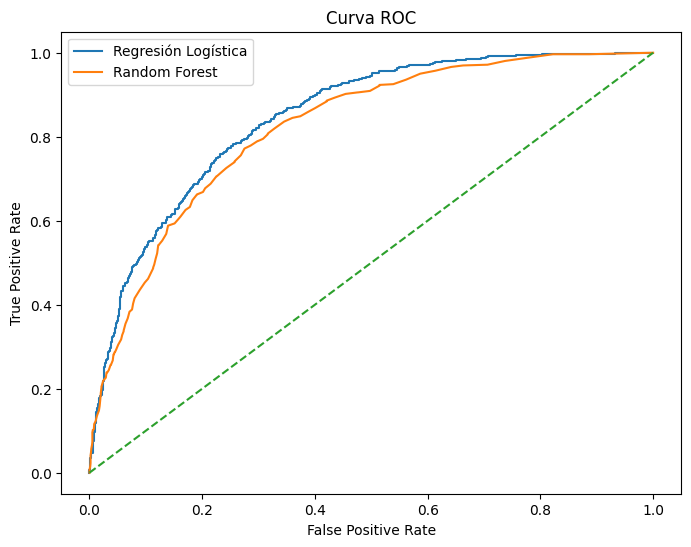

In [15]:
fpr_logistic, tpr_logistic, _ = roc_curve(y_test, y_prob_logistic)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8,6))
plt.plot(fpr_logistic, tpr_logistic, label="Regresión Logística")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("Curva ROC")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

## Análisis crítico de los modelos

A partir de las métricas obtenidas se observa que la **Regresión Logística presenta un mejor desempeño general** en comparación con el modelo Random Forest. Este modelo obtuvo valores superiores en accuracy, precision, recall y F1-score, además de un mayor valor de ROC-AUC.

Esto indica que la Regresión Logística logra capturar de manera más efectiva los patrones presentes en los datos para predecir la cancelación de clientes.

En cuanto al análisis de ajuste del modelo, no se observan indicios claros de **overfitting** ni **underfitting**. Los modelos presentan un desempeño equilibrado en el conjunto de prueba y logran identificar tanto clientes que permanecen como clientes que cancelan el servicio.

El hecho de que la Regresión Logística haya superado al Random Forest sugiere que las relaciones entre las variables del dataset pueden ser capturadas adecuadamente por un modelo relativamente simple después del proceso de preprocesamiento y estandarización.

Por esta razón, la **Regresión Logística se considera el modelo más adecuado para continuar con el análisis e interpretación de los factores que influyen en la cancelación de clientes**.

## Análisis de la importancia de las variables

Después de evaluar el desempeño de los modelos, se analizarán las variables más relevantes en la predicción de la cancelación de clientes.

Este análisis permite identificar qué factores tienen mayor influencia en el comportamiento de churn y facilita la interpretación de los resultados desde una perspectiva de negocio.

Para ello se utilizarán dos enfoques:

- **Coeficientes de la Regresión Logística**, que indican la dirección e intensidad del efecto de cada variable sobre la probabilidad de cancelación.
- **Importancia de variables de Random Forest**, que muestra qué variables contribuyen más a las decisiones del modelo.

##Random Forest

In [16]:
feature_importance = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importancia",
    ascending=False
)

feature_importance.head(10)

,Variable,Importancia
12,cargo_total,0.171453
3,antiguedad_meses,0.149729
11,cargo_mensual,0.133905
13,cargo_diario,0.131840
15,servicio_internet_Fiber optic,0.042339
24,metodo_pago_Electronic check,0.038736
22,tipo_contrato_Two year,0.030808
14,genero_Male,0.025051
10,factura_digital,0.023034
21,tipo_contrato_One year,0.021075


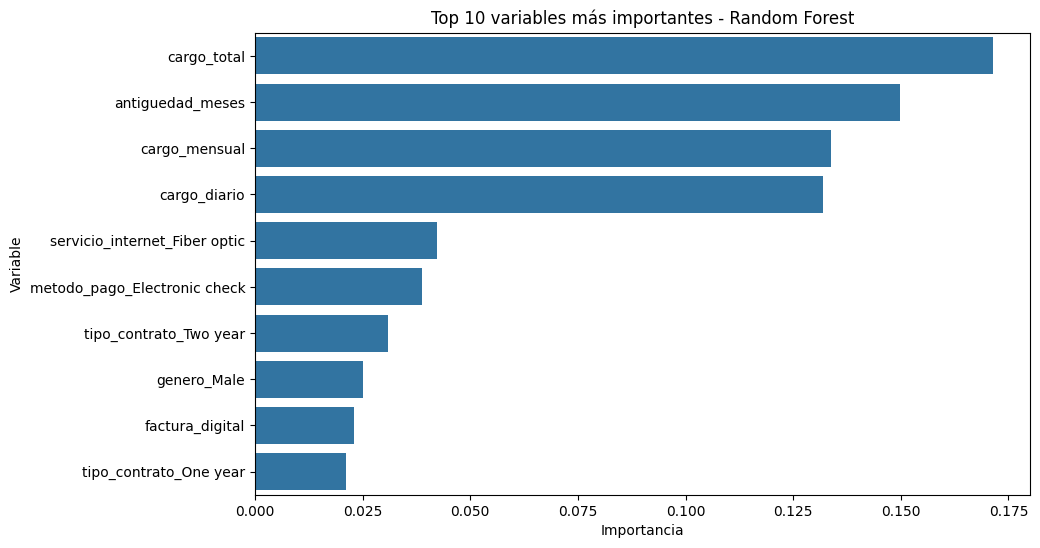

In [17]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importancia",
    y="Variable"
)

plt.title("Top 10 variables más importantes - Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()

##Regresión Logística

In [18]:
coef_df = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": logistic_model.coef_[0]
})

coef_df = coef_df.sort_values(by="Coeficiente", ascending=False)

coef_df.head(10)

,Variable,Coeficiente
15,servicio_internet_Fiber optic,0.952605
12,cargo_total,0.648036
24,metodo_pago_Electronic check,0.392360
10,factura_digital,0.369997
8,streaming_tv,0.316066
0,adulto_mayor,0.260454
9,streaming_peliculas,0.222282
5,lineas_multiples,0.214073
6,proteccion_dispositivo,0.030661
25,metodo_pago_Mailed check,0.013630


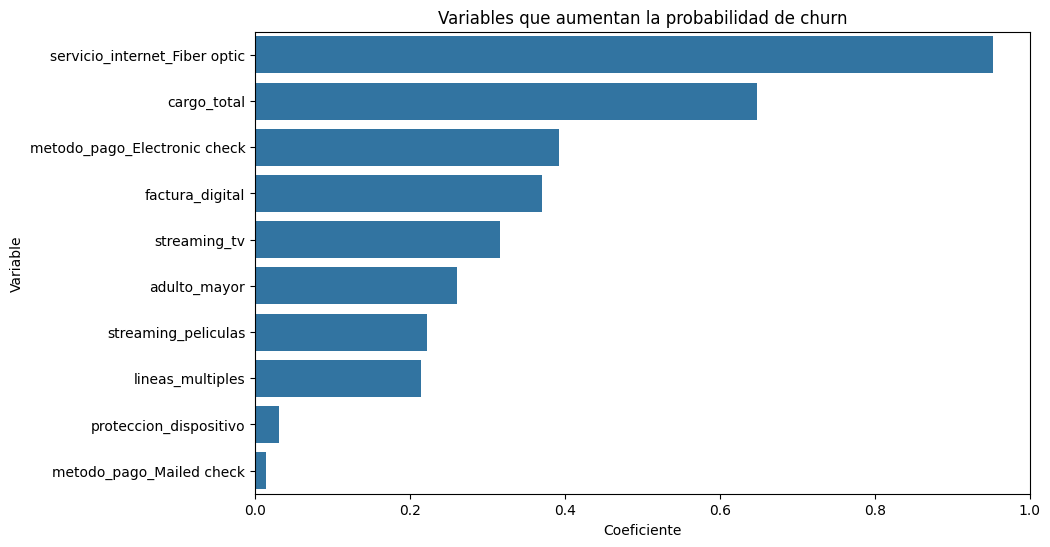

In [19]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=coef_df.head(10),
    x="Coeficiente",
    y="Variable"
)

plt.title("Variables que aumentan la probabilidad de churn")
plt.xlabel("Coeficiente")
plt.ylabel("Variable")
plt.show()

In [20]:
coef_df_negative = coef_df.sort_values(by="Coeficiente", ascending=True)

coef_df_negative.head(10)

,Variable,Coeficiente
3,antiguedad_meses,-1.372130
22,tipo_contrato_Two year,-1.222796
21,tipo_contrato_One year,-0.683303
7,soporte_tecnico,-0.377126
16,servicio_internet_No,-0.326005
19,respaldo_online_No internet service,-0.326005
17,seguridad_online_No internet service,-0.326005
4,servicio_telefono,-0.311584
18,seguridad_online_Yes,-0.260051
13,cargo_diario,-0.112508


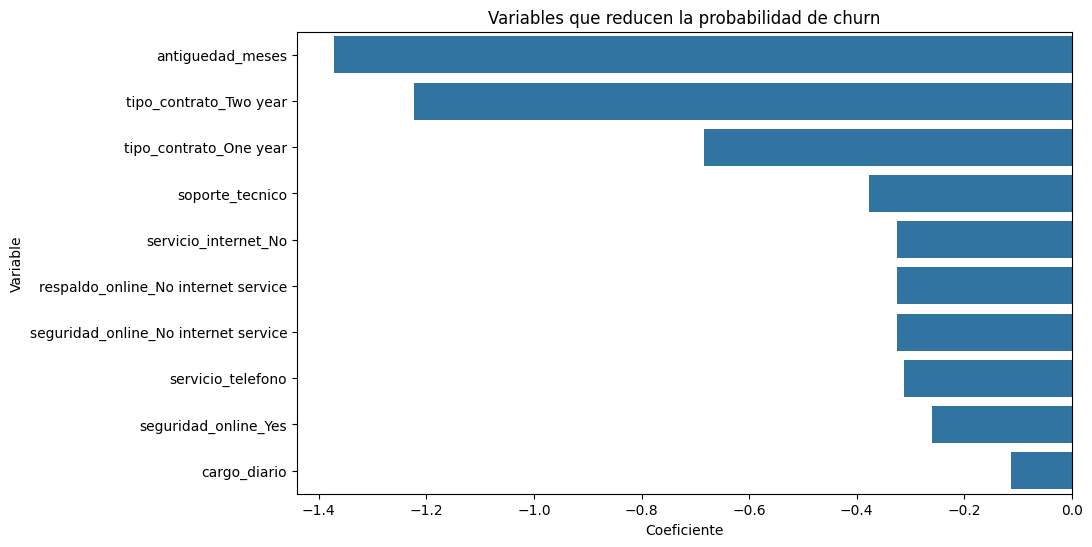

In [21]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=coef_df_negative.head(10),
    x="Coeficiente",
    y="Variable"
)

plt.title("Variables que reducen la probabilidad de churn")
plt.xlabel("Coeficiente")
plt.ylabel("Variable")
plt.show()

## Interpretación de la importancia de las variables

El análisis de importancia de variables permite identificar qué factores tienen mayor influencia en la cancelación de clientes (churn). Para ello se analizaron dos enfoques: la importancia de variables del modelo **Random Forest** y los **coeficientes de la Regresión Logística**.

### Variables más importantes según Random Forest

El modelo Random Forest indica que las variables con mayor impacto en la predicción del churn están principalmente relacionadas con el comportamiento financiero del cliente y su tiempo de permanencia en la empresa.

Entre las variables más relevantes se encuentran:

- **cargo_total**
- **antiguedad_meses**
- **cargo_mensual**
- **cargo_diario**
- **servicio_internet_Fiber optic**
- **metodo_pago_Electronic check**
- **tipo_contrato**

Esto sugiere que los factores económicos y la duración de la relación con el cliente son determinantes para predecir la cancelación.

### Variables que aumentan la probabilidad de cancelación

De acuerdo con los coeficientes de la Regresión Logística, las variables con coeficientes positivos incrementan la probabilidad de churn. Entre las más relevantes se encuentran:

- **servicio_internet_Fiber optic**
- **cargo_total**
- **metodo_pago_Electronic check**
- **factura_digital**
- **streaming_tv**
- **adulto_mayor**

Esto indica que algunos tipos de servicio, ciertos métodos de pago y mayores cargos asociados al servicio pueden estar relacionados con una mayor probabilidad de cancelación.

### Variables que reducen la probabilidad de cancelación

Por otro lado, los coeficientes negativos indican variables que están asociadas con una mayor permanencia del cliente en la empresa. Las más destacadas son:

- **antiguedad_meses**
- **tipo_contrato_Two year**
- **tipo_contrato_One year**
- **soporte_tecnico**
- **seguridad_online**
- **respaldo_online**

Estos resultados sugieren que los clientes con mayor tiempo en la empresa, contratos de mayor duración y servicios adicionales tienden a permanecer más tiempo con la compañía.

### Conclusión del análisis

En conjunto, los resultados muestran que la cancelación de clientes está fuertemente relacionada con tres factores principales:

- **Antigüedad del cliente**
- **Tipo de contrato**
- **Características del servicio y costos asociados**

Esto refuerza los hallazgos obtenidos durante el análisis exploratorio y confirma que los clientes más nuevos, con contratos más flexibles y ciertos tipos de servicio presentan mayor probabilidad de cancelar el servicio.